# Aufgabe 2

## Bestimmen der Dämpfungskonstante

In der zweite Aufgabe haben wir die Scheibe als Kreisel aufgezogen. Dabei wurde wieder ein Seil um die Fadentrommel gewickelt, dieses mal aber ein etwas dickerer, und nach dem Aufwickeln ist durch ziehem am Ende des Fadens die Scheibe wieder in eine Drehung versetzt worden. Gefordert war, dass die Drehung mindestens 4000 Umdrehungen die Minute durchführt und dann wurde über 2 Minuten der Geschwindigkeitsabfall dokumentiert. Folgende Messungen wurden Dokumentiert:
| t [s] |  RPM   |
|-------|--------|
| 0     | 4041  |
| 10    | 3889  |
| 20    | 3739  |
| 30    | 3606  |
| 40    | 3471  |
| 50    | 3338  |
| 60    | 3214  |
| 70    | 3101  |
| 80    | 2987  |
| 90    | 2875  |
| 100   | 2758  |
| 110   | 2653  |
| 120   | 2566  |


Startfrequenz n₀: 67.318 Hz
Dämpfungskonstante β: 0.00380 1/s
Standardabweichung der Residuen: 0.07200 Hz


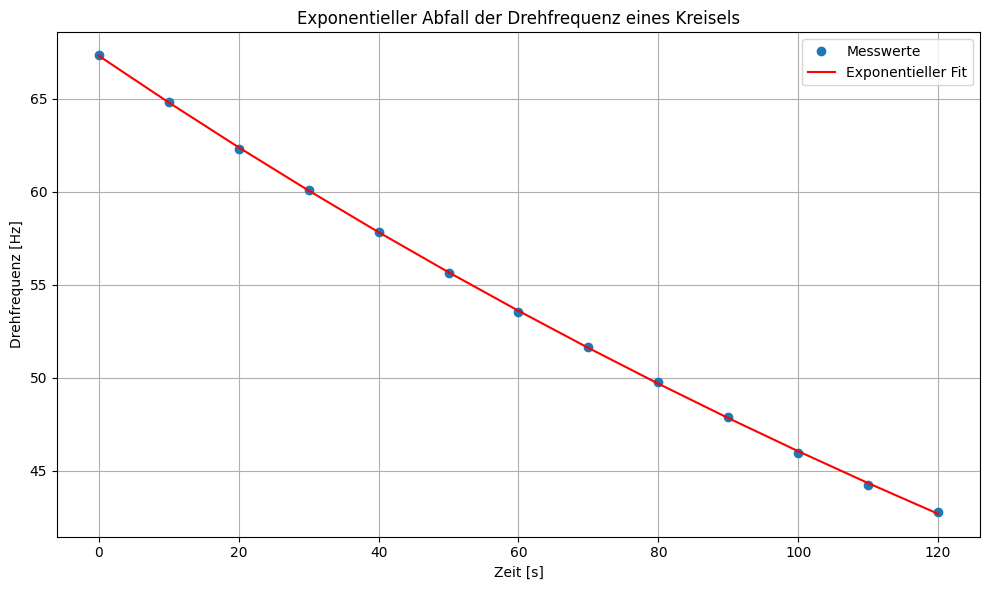

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSV einlesen
df = pd.read_csv('Daten/Aufgabe_2.csv')
df.columns = ['t[s]', 'RPM']

t = df['t[s]'].values
rpm = df['RPM'].values


# Umrechnen von RPM in Umdrehungen pro Sekunde (Hz)
n = rpm / 60

# Definition der Modellfunktion: Exponentieller Zerfall
def exp_modell(t, n0, beta):
    return n0 * np.exp(-beta * t)

# Fit der Daten mit Anfangsschätzung für n0 und beta
params, _ = curve_fit(exp_modell, t, n, p0=(n[0], 0.01))
n0_fit, beta_fit = params

# Berechnung der Fit-Werte
n_fit = exp_modell(t, n0_fit, beta_fit)

# Berechnung der Residuen und der Standardabweichung
residuen = n - n_fit
std_abw = np.std(residuen, ddof=1)

# Ausgabe der Fitparameter und Unsicherheit
print(f"Startfrequenz n₀: {n0_fit:.3f} Hz")
print(f"Dämpfungskonstante β: {beta_fit:.5f} 1/s")
print(f"Standardabweichung der Residuen: {std_abw:.5f} Hz")

# Plot der Messdaten und des exponentiellen Fits
plt.figure(figsize=(10, 6))
plt.plot(t, n, 'o', label='Messwerte')
plt.plot(t, n_fit, '-', label=f'Exponentieller Fit', color='red')
plt.xlabel("Zeit [s]")
plt.ylabel("Drehfrequenz [Hz]")
plt.title("Exponentieller Abfall der Drehfrequenz eines Kreisels")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


